In [8]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np
# import math
# import random

# def plot_graph_from_coordinates(coordinates, separate_points=None, separate_points_labels=None):
#     G = nx.Graph()
#     for i, coord in enumerate(coordinates):
#         G.add_node(i, pos=coord)
#     for i in range(len(coordinates) - 1):
#         current_coord = coordinates[i]
#         next_coord = coordinates[i + 1]
#         dist = np.linalg.norm(np.array(current_coord) - np.array(next_coord))
#         G.add_edge(i, i + 1, weight=dist)
    
#     if separate_points:
#         for i, coord in enumerate(separate_points):
#             G.add_node(len(coordinates) + i, pos=coord)

#     pos = nx.get_node_attributes(G, 'pos')
#     labels = {i: f"{coord}" for i, coord in enumerate(coordinates)}

#     nx.draw(G, pos, with_labels=True, labels=labels, node_size=200, node_color='skyblue', font_size=6)
#     nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1.0, alpha=0.5)
    
#     if separate_points:
#         nx.draw_networkx_nodes(G, pos, nodelist=range(len(coordinates), len(coordinates) + len(separate_points)), node_size=200, node_color='green')
#         if separate_points_labels:
#             for i, coord in enumerate(separate_points):
#                 plt.text(coord[0], coord[1], f"Prob: {separate_points_labels[i]:.4f}\n", fontsize=10, ha='center', va='center', color='black')

#     plt.title('Graph from Cartesian Coordinates')
#     plt.xlabel('X-axis') 
#     plt.ylabel('Y-axis')
#     plt.show()

# states = [(0,0),(0,1),(0,2),(1,2), (2,2), (3, 2), (4,2)]

# observations = [(-0.2, -45.5), (0.3, -46.3), (0.5, -47.1), (0.8, -48.2), (1.0, -49.0),
#                 (-0.4, -45.8), (1.3, -47.5), (1.5, -48.0), (2.0, -46.7), (2.3, -47.3),
#                 (1.2, -48.1), (-0.7, -45.2), (0.6, -46.5), (-0.5, -47.8), (0.7, -48.3),
#                 (1.4, -49.2), (1.6, -46.8), (1.9, -45.6), (0.9, -47.9), (-0.1, -46.4), (0.4, -45.9),
#                 (-0.8,0), (0.6,1), (-0.9,2), (1.1,2.1), (1.8,1.7), (3.1, 2.2), (4.2,1.5)]

# obs = -55+10*np.random.rand(1, 50)
# obs_1 = -1+2*np.random.rand(1, 50)

# arr = np.concatenate((obs_1, obs))

# qty = 50
# # arr = np.concat(obs_1, obs)
# # print(arr)
# observations.extend(arr)

# print(observations)


In [7]:
# import numpy as np

# observations = [(-0.2, -45.5), (0.3, -46.3), (0.5, -47.1), (0.8, -48.2), (1.0, -49.0),
#                 (-0.4, -45.8), (1.3, -47.5), (1.5, -48.0), (2.0, -46.7), (2.3, -47.3),
#                 (1.2, -48.1), (-0.7, -45.2), (0.6, -46.5), (-0.5, -47.8), (0.7, -48.3),
#                 (1.4, -49.2), (1.6, -46.8), (1.9, -45.6), (0.9, -47.9), (-0.1, -46.4), (0.4, -45.9),
#                 (-0.8, 0), (0.6, 1), (-0.9, 2), (1.1, 2.1), (1.8, 1.7), (3.1, 2.2), (4.2, 1.5)]

# obs = -55 + 10 * np.random.rand(74)  
# obs_1 = -1 + 2 * np.random.rand(74)  

# new_observations = list(zip(obs_1, obs))  
# new_observations.extend(observations)  
# print(observations)
# print(len(new_observations))

In [ ]:
import numpy as np
from math import log

def pairwise_distances(A, B):
    A = np.array(A)
    B = np.array(B)
    diff = A[:, None, :] - B[None, :, :]
    return np.sqrt(np.sum(diff**2, axis=-1))

def calculate_transition_matrix(states, zVec):
    n_states = len(states)
    n_obs = len(zVec)
    TRANS = np.zeros((n_states, n_states, n_obs))
    state_distances = pairwise_distances(states, states)

    beta = np.median(zVec) / log(2) if np.median(zVec) > 0 else 1

    for k in range(n_obs):
        for i in range(n_states):
            for j in range(n_states):
                dij = abs(state_distances[i, j] - zVec[k])
                TRANS[i, j, k] = (1 / beta) * np.exp(-dij / beta)

        if np.sum(TRANS[:, :, k]) > 0:
            TRANS[:, :, k] /= np.sum(TRANS[:, :, k])

    return TRANS

def calculate_emission_matrix(states, observations):
    distances = pairwise_distances(states, observations)
    sigz = max(1.4 * np.median(distances), 1e-3)

    EMIS = (1 / (np.sqrt(2 * np.pi) * sigz)) * np.exp(-0.5 * (distances / sigz) ** 2)
    return EMIS

def viterbi_algorithm(states, observations, zVec, PRIOR):
    n_states = len(states)
    T = len(observations)

    TRANS = calculate_transition_matrix(states, zVec)
    EMIS = calculate_emission_matrix(states, observations)

    score = np.zeros((n_states, T))
    pred = np.zeros((n_states, T), dtype=int)

    score[:, 0] = PRIOR * EMIS[:, 0]

    for t in range(1, T):
        temp_score = score[:, t - 1][:, None] * TRANS[:, :, t - 1]
        score[:, t] = np.max(temp_score, axis=0) * EMIS[:, t]
        pred[:, t] = np.argmax(temp_score, axis=0)

    IT = np.zeros(T, dtype=int)
    IT[-1] = np.argmax(score[:, -1])

    for t in range(T - 1, 0, -1):
        IT[t - 1] = pred[IT[t], t]

    return IT


states = np.array([(0,0),(0,1),(0,2),(1,2),(2,2),(3,2),(4,2)])

observations_fixed = [(-0.2, -45.5), (0.3, -46.3), (0.5, -47.1), (0.8, -48.2), (1.0, -49.0),
                (-0.4, -45.8), (1.3, -47.5), (1.5, -48.0), (2.0, -46.7), (2.3, -47.3),
                (1.2, -48.1), (-0.7, -45.2), (0.6, -46.5), (-0.5, -47.8), (0.7, -48.3),
                (1.4, -49.2), (1.6, -46.8), (1.9, -45.6), (0.9, -47.9), (-0.1, -46.4), (0.4, -45.9),
                (-0.8, 0), (0.6, 1), (-0.9, 2), (1.1, 2.1), (1.8, 1.7), (3.1, 2.2), (4.2, 1.5)]

obs = -55 + 10 * np.random.rand(74)  
obs_1 = -1 + 2 * np.random.rand(74)  
new_observations = list(zip(obs_1, obs))  
new_observations.extend(observations_fixed)  

observations = np.array(new_observations)

zVec = np.array([np.linalg.norm(observations[i] - observations[i+1]) for i in range(len(observations)-1)])

PRIOR = np.ones(len(states)) / len(states)

matched_states = viterbi_algorithm(states, observations, zVec, PRIOR)

print("Matched States (indices):", matched_states)


Matched States (indices): [5 0 2 0 4 4 1 5 4 5 6 2 0 4 3 6 3 6 2 0 6 6 0 5 0 6 5 5 6 2 0 6 0 3 6 6 4
 1 3 1 6 0 1 4 0 6 2 3 1 6 4 5 0 5 6 1 6 0 5 6 3 3 2 5 4 1 0 5 0 6 0 3 0 6
 0 1 0 1 0 5 3 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
import numpy as np
import networkx as nx
from geopy.distance import geodesic
from math import log

# ---------------------------
# Utility functions
# ---------------------------
def pairwise_distances(A, B):
    A = np.array(A)
    B = np.array(B)
    diff = A[:, None, :] - B[None, :, :]
    return np.sqrt(np.sum(diff**2, axis=-1))

def calculate_graph_distances(G, states):
    n_states = len(states)
    distances = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            if i != j:
                try:
                    distances[i, j] = nx.shortest_path_length(
                        G, source=tuple(states[i]), target=tuple(states[j]), weight="weight"
                    )
                except nx.NetworkXNoPath:
                    distances[i, j] = np.inf
    return distances

def calculate_transition_matrix(states, zVec, state_distances):
    n_states = len(states)
    n_obs = len(zVec)
    TRANS = np.zeros((n_states, n_states, n_obs))
    beta = np.median(zVec) / log(2) if np.median(zVec) > 0 else 1

    for k in range(n_obs):
        for i in range(n_states):
            for j in range(n_states):
                dij = abs(state_distances[i, j] - zVec[k])
                TRANS[i, j, k] = (1 / beta) * np.exp(-dij / beta)

        # Normalize per row
        row_sums = np.sum(TRANS[:, :, k], axis=1)
        TRANS[:, :, k] = np.divide(TRANS[:, :, k], row_sums[:, None], where=row_sums[:, None] != 0)

    return TRANS

def calculate_emission_matrix(states, observations):
    distances = pairwise_distances(states, observations)
    sigz = max(1.4 * np.median(distances), 1e-3)
    EMIS = (1 / (np.sqrt(2 * np.pi) * sigz)) * np.exp(-0.5 * (distances / sigz) ** 2)
    return EMIS

def viterbi_algorithm(states, observations, zVec, PRIOR, state_distances):
    n_states = len(states)
    T = len(observations)

    TRANS = calculate_transition_matrix(states, zVec, state_distances)
    EMIS = calculate_emission_matrix(states, observations)

    score = np.zeros((n_states, T))
    pred = np.zeros((n_states, T), dtype=int)

    score[:, 0] = PRIOR * EMIS[:, 0]

    for t in range(1, T):
        temp_score = score[:, t - 1][:, None] * TRANS[:, :, t - 1]
        pred[:, t] = np.argmax(temp_score, axis=0)
        score[:, t] = np.max(temp_score, axis=0) * EMIS[:, t]

    IT = np.zeros(T, dtype=int)
    IT[-1] = np.argmax(score[:, -1])

    for t in range(T - 1, 0, -1):
        IT[t - 1] = pred[IT[t], t]

    return IT

# ---------------------------
# Toy Example Setup
# ---------------------------
states = np.array([(0,0),(0,1),(0,2),(1,2),(2,2),(3,2),(4,2)])

# Build road graph (chain along states)
G = nx.Graph()
edges = [
    ((0,0),(0,1)), 
    ((0,1),(0,2)), 
    ((0,2),(1,2)), 
    ((1,2),(2,2)), 
    ((2,2),(3,2)), 
    ((3,2),(4,2))
]
for u, v in edges:
    G.add_edge(u, v, weight=geodesic(u, v).meters)

# Example noisy observations near states
observations = [(-0.2, -45.5), (0.3, -46.3), (0.5, -47.1), (0.8, -48.2), (1.0, -49.0),
                 (-0.4, -45.8), (1.3, -47.5), (1.5, -48.0), (2.0, -46.7), (2.3, -47.3),
                 (1.2, -48.1), (-0.7, -45.2), (0.6, -46.5), (-0.5, -47.8), (0.7, -48.3),
                 (1.4, -49.2), (1.6, -46.8), (1.9, -45.6), (0.9, -47.9), (-0.1, -46.4), (0.4, -45.9),
                 (-0.8, 0), (0.6, 1), (-0.9, 2), (1.1, 2.1), (1.8, 1.7), (3.1, 2.2), (4.2, 1.5)]

# Step lengths between consecutive observations
zVec = np.array([geodesic(observations[i], observations[i+1]).meters for i in range(len(observations)-1)])

# Prior uniform
PRIOR = np.ones(len(states)) / len(states)

# Road distances between states
state_distances = calculate_graph_distances(G, states)

# Run Viterbi
matched_states = viterbi_algorithm(states, observations, zVec, PRIOR, state_distances)
print(len(observations))
print(len(matched_states))
print("Matched States (indices):", matched_states)

28
28
Matched States (indices): [0 1 0 1 0 4 6 6 5 6 4 0 2 0 1 2 0 1 4 6 5 0 2 4 6 5 6 5]


In [4]:
# import numpy as np
# from math import log
# from geopy.distance import geodesic
# from scipy.spatial.distance import cdist

# def calculate_transition_matrix(states, zVec, observations):
#     n_states = len(states)
#     n_obs = len(zVec)
#     TRANS = np.zeros((n_states, n_states, n_obs))
#     state_distances = cdist(states, states)

#     beta_values = []
#     for k in range(len(zVec)):
#         great_circle_distance = np.linalg.norm(np.array(observations[k]) - np.array(observations[k + 1]))
#         route_distances = np.linalg.norm(np.array(states[k]) - np.array(states[k + 1]))
#         diff_distance = great_circle_distance - route_distances
#         beta_values.append(diff_distance)
#     mediant_value = np.median(beta_values) if len(beta_values) > 0 else 0
#     beta = mediant_value / log(2) if mediant_value != 0 else 1
#     print(beta)
#     # beta = 30
#     for k in range(n_obs):
#         for i in range(n_states):
#             for j in range(n_states):
#                 dij = abs(state_distances[i, j] - zVec[k])
#                 TRANS[i, j, k] = (1 / beta) * np.exp(-dij / beta)

#             if np.sum(TRANS[i, :, k]) != 0:
#                 TRANS[i, :, k] /= np.sum(TRANS[i, :, k])

#     return TRANS

# def calculate_emission_matrix(states, observations):
#     n_states = len(states)
#     n_obs = len(observations)

#     distances = cdist(states, observations)
#     sigz = 1.4 * np.median(distances)

#     EMIS = (1 / (np.sqrt(2 * np.pi) * sigz)) * np.exp(-0.5 * (distances / sigz) ** 2)
#     return EMIS

# def viterbi_algorithm(states, observations, zVec, PRIOR):
#     n_states = len(states)
#     T = len(observations)

#     TRANS = calculate_transition_matrix(states, zVec, observations)
#     EMIS = calculate_emission_matrix(states, observations)

#     score = np.zeros((n_states, T))
#     pred = np.zeros((n_states, T), dtype=int)

#     score[:, 0] = PRIOR * EMIS[:, 0]

#     for t in range(1, T):
#         temp_score = score[:, t - 1][:, None] * TRANS[:, :, t - 1]
#         score[:, t] = np.max(temp_score, axis=0) * EMIS[:, t]
#         pred[:, t] = np.argmax(temp_score, axis=0)

#     IT = np.zeros(T, dtype=int)
#     IT[-1] = np.argmax(score[:, -1])

#     for t in range(T - 1, 0, -1):
#         IT[t - 1] = pred[IT[t], t]

#     return IT


# states = np.array(states)

# observations = np.array(observations)

# zVec_2 = np.array([np.linalg.norm(observations[i] - observations[i + 1]) for i in range(len(observations) - 1)])

# PRIOR_2 = np.ones(len(states)) / len(states)

# matched_states_2 = viterbi_algorithm(states, observations, zVec_2, PRIOR_2)

# print("Matched States for Subgraph 1:", matched_states_2)
import numpy as np
import networkx as nx
from geopy.distance import geodesic
from math import exp, sqrt, pi

# Step 1: Generate synthetic noisy observations
observations = [(-0.2, -45.5), (0.3, -46.3), (0.5, -47.1), (0.8, -48.2), (1.0, -49.0)]
obs = -55 + 10 * np.random.rand(74)  
obs_1 = -1 + 2 * np.random.rand(74)  
new_observations = list(zip(obs_1, obs))  
new_observations.extend(observations)

# Step 2: Define the graph states explicitly
states = [(0,0),(0,1),(0,2),(1,2),(2,2),(3,2),(4,2)]

G = nx.Graph()
for i in range(len(states)-1):
    p1, p2 = states[i], states[i+1]
    d = geodesic(p1, p2).meters
    G.add_node(i, pos=p1)
    G.add_node(i+1, pos=p2)
    G.add_edge(i, i+1, weight=d)

state_coords = {n: G.nodes[n]['pos'] for n in G.nodes}
state_list = list(G.nodes)

# Step 3: Compute pairwise graph distances
def calculate_graph_distances(graph, states):
    n_states = len(states)
    distances = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            if i != j:
                try:
                    path_length = nx.shortest_path_length(
                        graph, source=states[i], target=states[j], weight="weight"
                    )
                    distances[i, j] = path_length
                except nx.NetworkXNoPath:
                    distances[i, j] = np.inf
    return distances

state_distances = calculate_graph_distances(G, state_list)

# Step 4: Transition matrix
def calculate_transition_matrix(states, zVec, observations, state_distances):
    n_states = len(states)
    n_obs = len(zVec)
    TRANS = np.zeros((n_states, n_states, n_obs))
    beta = np.median(zVec) / np.log(2)
    for k in range(n_obs):
        for i in range(n_states):
            for j in range(n_states):
                dij = abs(state_distances[i, j] - zVec[k])
                TRANS[i, j, k] = (1 / beta) * exp(-dij / beta) if beta > 0 else 0
        row_sums = np.sum(TRANS[:, :, k], axis=1)
        TRANS[:, :, k] = np.divide(TRANS[:, :, k], row_sums[:, None], where=row_sums[:, None] != 0)
    return TRANS

# Step 5: Emission matrix
def calculate_emission_matrix(states, observations):
    n_states = len(states)
    n_obs = len(observations)
    distances = np.zeros((n_states, n_obs))
    for i in range(n_states):
        for j in range(n_obs):
            distances[i, j] = geodesic(state_coords[states[i]], observations[j]).meters
    sigz = 1.4826 * np.median(np.min(distances, axis=0))
    EMIS = (1 / (sqrt(2 * pi) * sigz)) * np.exp(-0.5 * (distances / sigz) ** 2)
    return EMIS

# Step 6: Viterbi algorithm
def viterbi_algorithm(states, observations, zVec, PRIOR, state_distances):
    n_states = len(states)
    T = len(observations)
    TRANS = calculate_transition_matrix(states, zVec, observations, state_distances)
    EMIS = calculate_emission_matrix(states, observations)
    score = np.zeros((n_states, T))
    pred = np.zeros((n_states, T), dtype=int)
    score[:, 0] = PRIOR * EMIS[:, 0]
    for t in range(1, T):
        temp_score = score[:, t - 1][:, None] * TRANS[:, :, t - 1]
        pred[:, t] = np.argmax(temp_score, axis=0)
        score[:, t] = np.max(temp_score, axis=0) * EMIS[:, t]
    IT = np.zeros(T, dtype=int)
    IT[-1] = np.argmax(score[:, -1])
    for t in range(T - 1, 0, -1):
        IT[t - 1] = pred[IT[t], t]
    return IT

zVec = [geodesic(new_observations[i], new_observations[i + 1]).meters for i in range(len(new_observations) - 1)]
PRIOR = np.ones(len(state_list)) / len(state_list)
matched_states = viterbi_algorithm(state_list, new_observations, zVec, PRIOR, state_distances)

# Print results
print("Matched node sequence (indices):", matched_states.tolist())


Matched node sequence (indices): [6, 0, 6, 0, 2, 6, 4, 1, 0, 0, 2, 6, 0, 2, 0, 2, 6, 0, 3, 0, 1, 0, 6, 0, 0, 1, 6, 1, 0, 1, 4, 5, 1, 4, 0, 1, 2, 6, 3, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


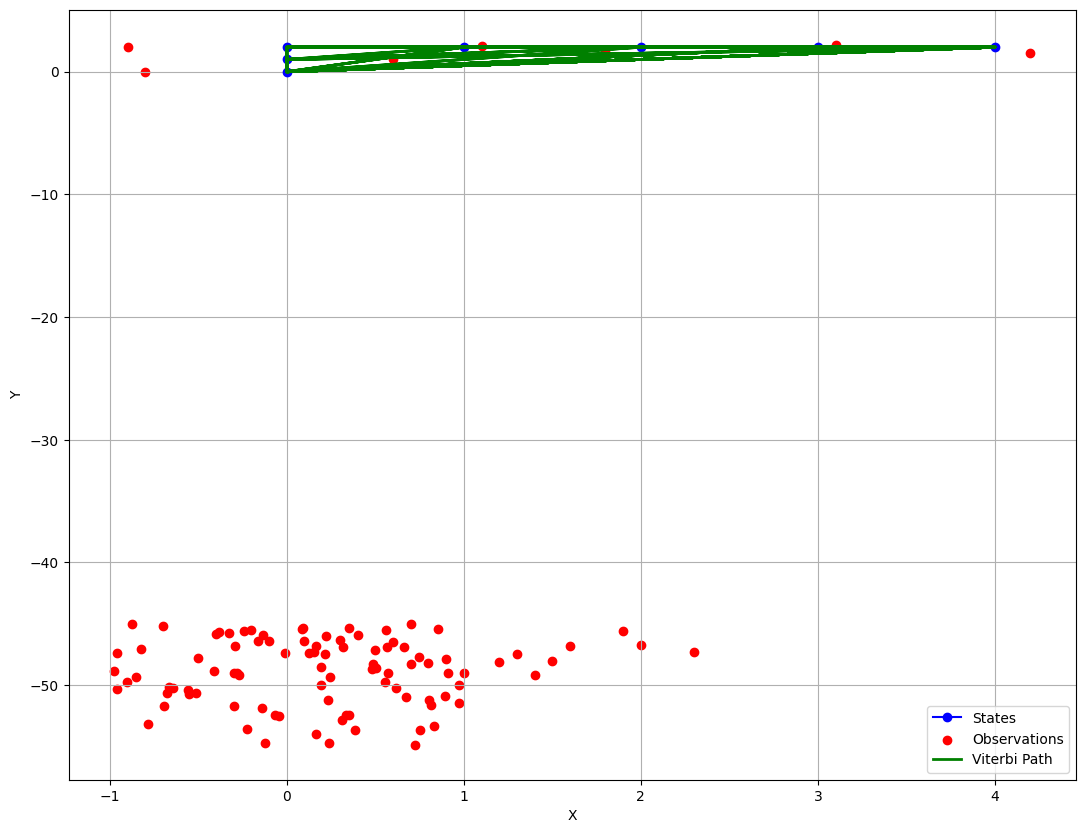

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from math import log

def pairwise_distances(A, B):
    A = np.array(A)
    B = np.array(B)
    diff = A[:, None, :] - B[None, :, :]
    return np.sqrt(np.sum(diff**2, axis=-1))

def calculate_transition_matrix(states, zVec):
    n_states = len(states)
    n_obs = len(zVec)
    TRANS = np.zeros((n_states, n_states, n_obs))
    state_distances = pairwise_distances(states, states)

    beta = np.median(zVec) / log(2) if np.median(zVec) > 0 else 1

    for k in range(n_obs):
        for i in range(n_states):
            for j in range(n_states):
                dij = abs(state_distances[i, j] - zVec[k])
                TRANS[i, j, k] = (1 / beta) * np.exp(-dij / beta)

        if np.sum(TRANS[:, :, k]) > 0:
            TRANS[:, :, k] /= np.sum(TRANS[:, :, k])

    return TRANS

def calculate_emission_matrix(states, observations):
    distances = pairwise_distances(states, observations)
    sigz = max(1.4 * np.median(distances), 1e-3)

    EMIS = (1 / (np.sqrt(2 * np.pi) * sigz)) * np.exp(-0.5 * (distances / sigz) ** 2)
    return EMIS

def viterbi_algorithm(states, observations, zVec, PRIOR):
    n_states = len(states)
    T = len(observations)

    TRANS = calculate_transition_matrix(states, zVec)
    EMIS = calculate_emission_matrix(states, observations)

    score = np.zeros((n_states, T))
    pred = np.zeros((n_states, T), dtype=int)

    score[:, 0] = PRIOR * EMIS[:, 0]

    for t in range(1, T):
        temp_score = score[:, t - 1][:, None] * TRANS[:, :, t - 1]
        score[:, t] = np.max(temp_score, axis=0) * EMIS[:, t]
        pred[:, t] = np.argmax(temp_score, axis=0)

    IT = np.zeros(T, dtype=int)
    IT[-1] = np.argmax(score[:, -1])

    for t in range(T - 1, 0, -1):
        IT[t - 1] = pred[IT[t], t]

    return IT


# # --- States ---
# states = np.array([(0,0),(0,1),(0,2),(1,2),(2,2),(3,2),(4,2)])

# # --- Observations ---
# observations_fixed = [(-0.2, -45.5), (0.3, -46.3), (0.5, -47.1), (0.8, -48.2), (1.0, -49.0),
#                 (-0.4, -45.8), (1.3, -47.5), (1.5, -48.0), (2.0, -46.7), (2.3, -47.3),
#                 (1.2, -48.1), (-0.7, -45.2), (0.6, -46.5), (-0.5, -47.8), (0.7, -48.3),
#                 (1.4, -49.2), (1.6, -46.8), (1.9, -45.6), (0.9, -47.9), (-0.1, -46.4), (0.4, -45.9),
#                 (-0.8, 0), (0.6, 1), (-0.9, 2), (1.1, 2.1), (1.8, 1.7), (3.1, 2.2), (4.2, 1.5)]

obs = -55 + 10 * np.random.rand(74)  
obs_1 = -1 + 2 * np.random.rand(74)  
new_observations = list(zip(obs_1, obs))  
new_observations.extend(observations_fixed)  

observations = np.array(new_observations)

# --- zVec (step distances between observations) ---
zVec = np.array([np.linalg.norm(observations[i] - observations[i+1]) for i in range(len(observations)-1)])

# --- Prior (uniform) ---
PRIOR = np.ones(len(states)) / len(states)

# --- Run Viterbi ---
matched_state_indices = viterbi_algorithm(states, observations, zVec, PRIOR)
matched_states = states[matched_state_indices]

# --- Plot ---
plt.figure(figsize=(13, 10))
plt.plot(states[:, 0], states[:, 1], 'bo-', label='States')  # States as blue line
plt.scatter(observations[:, 0], observations[:, 1], c='r', label='Observations')  # Observations as red dots
plt.plot(matched_states[:, 0], matched_states[:, 1], 'g-', linewidth=2, label='Viterbi Path')  # Viterbi path
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()


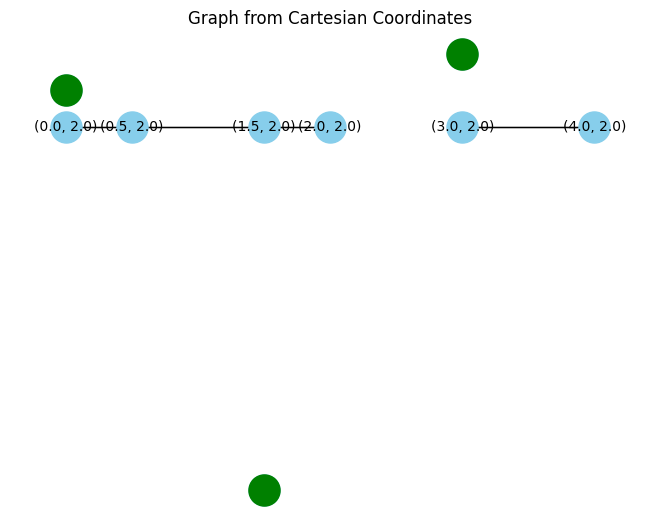

Emission Matrix (EMIS):
 [[0.18965566 0.14299806 0.06849631]
 [0.18436988 0.16470598 0.09347629]
 [0.14705616 0.184422   0.14693151]
 [0.12065694 0.17928208 0.16923655]
 [0.06855442 0.14299806 0.1894949 ]
 [0.0310679  0.09097387 0.16923655]]

Transition Matrix (TRANS):
 [[[0.19218726 0.08931129]
  [0.32531242 0.15117585]
  [0.93207901 0.43314619]
  [0.70230219 0.32636667]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.32531242 0.1626375 ]
  [0.19218726 0.09608258]
  [0.55065132 0.275294  ]
  [0.93207901 0.46598591]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.93207901 0.46598591]
  [0.55065132 0.275294  ]
  [0.19218726 0.09608258]
  [0.32531242 0.1626375 ]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.70230219 0.32636667]
  [0.93207901 0.43314619]
  [0.32531242 0.15117585]
  [0.19218726 0.08931129]
  [0.         0.        ]
  [0.         0.        ]]

 [[0.         0.        ]
  [0.         0.        ]
  [0.         0.        ]
  [0.         0.   

In [81]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from math import exp, sqrt, pi

def plot_graph_from_coordinates(states, observations=None, observations_labels=None):
    G = nx.Graph()
    
    states = np.array(states)

    for i, coord in enumerate(states):
        G.add_node(i, pos=tuple(coord))
    
    for i in range(len(states) - 1):
        current_coord = states[i]
        next_coord = states[i + 1]
        
        if np.array_equal(current_coord, [2, 2]) and np.array_equal(next_coord, [3, 2]):
            continue
        
        dist = np.linalg.norm(current_coord - next_coord)
        G.add_edge(i, i + 1, weight=dist)
    
    if observations is not None:
        observations = np.array(observations)
        for i, coord in enumerate(observations):
            G.add_node(len(states) + i, pos=tuple(coord))

    pos = nx.get_node_attributes(G, 'pos')
    
    labels = {i: f"{tuple(coord)}" for i, coord in enumerate(states)}

    nx.draw(G, pos, with_labels=True, labels=labels, node_size=500, node_color='skyblue', font_size=10)
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1.0, alpha=0.5)
    
    if observations is not None:
        nx.draw_networkx_nodes(G, pos, nodelist=range(len(states), len(states) + len(observations)), node_size=500, node_color='green')
        if observations_labels:
            for i, coord in enumerate(observations):
                plt.text(coord[0], coord[1], f"Prob: {observations_labels[i]:.4f}\n", fontsize=10, ha='center', va='center', color='black')

    plt.title('Graph from Cartesian Coordinates')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

    return states, G

states = [(0, 2), (0.5, 2), (1.5, 2), (2, 2), (3, 2), (4, 2)]
observations = [(0, 2.05), (1.5, 1.5), (3, 2.1)]

states, graph = plot_graph_from_coordinates(states, observations)

states = np.array(states)
observations = np.array(observations)
pairwise_distances = np.linalg.norm(np.diff(observations, axis=0), axis=1)

TRANS = np.zeros((len(states), len(states), len(observations) - 1))
# TRANS = np.zeros((len(states), len(states)))

beta = 0.95  

n = len(states)
for k in range(len(observations) - 1):
    for i in range(n):
        for j in range(n):
            if nx.has_path(graph, i, j):  
                xtemp = np.linalg.norm(states[i] - states[j])
                dij = abs(xtemp - pairwise_distances[k])
                TRANS[i, j, k] = (1 / beta) * exp(-dij / beta)        
        valid_indices = np.isfinite(TRANS[i, :, k])
        if np.sum(TRANS[i, valid_indices, k]) > 0:
            TRANS[i, valid_indices, k] = TRANS[i, valid_indices, k] / np.sum(TRANS[i, valid_indices, k])

sigztemp = np.array([np.linalg.norm(observations[i] - states[j]) for i in range(len(observations)) for j in range(len(states))])
sigz = 1.4 * np.median(sigztemp)

EMIS = np.zeros((len(states), len(observations)))
for i in range(len(observations)):
    for j in range(len(states)):
        EMIS[j, i] = (1 / (sqrt(2 * pi) * sigz)) * exp(-0.5 * ((np.linalg.norm(observations[i] - states[j])) / sigz) ** 2)

print("Emission Matrix (EMIS):\n", EMIS)
print("\nTransition Matrix (TRANS):\n", TRANS)


In [82]:
import numpy as np
from math import exp, sqrt, pi

pairwise_distances3 = []
for i in range(len(observations) - 1):
    x1, y1 = observations[i]
    x2, y2 = observations[i + 1]
    distance = sqrt((x2 - x1)**2 + (y2 - y1)**2)
    pairwise_distances3.append(distance)

beta = 0.95  

n3 = len(states)
for k in range(len(observations)-1):
    for i in range(n3):
        for j in range(n3):
            xtemp3 = np.linalg.norm(states[i] - states[j])
            dij3 = abs(xtemp3 - pairwise_distances3[k])
            TRANS[i, j, k] = (1 / beta) * exp(-dij3 / beta)
        TRANS[i, :, k] = TRANS[i, :, k] / np.sum(TRANS[i, :, k])

sigztemp3 = []
for i in range(len(observations)):
    for j in range(len(states)):
        sigztemp3.append(np.linalg.norm(observations[i] - states[j]))
sigz3 = 1.4 * np.median(sigztemp3)

EMIS = np.zeros((len(states), len(observations)))
for i in range(len(observations)):
    for j in range(len(states)):
        EMIS[j, i] = (1 / (sqrt(2 * pi) * sigz3)) * exp(-0.5 * ((np.linalg.norm(observations[i] - states[j])) / sigz3) ** 2)
    
# seq = [1, 2, 3, 4]
seq3 = np.arange(1, len(observations)+1)

PRIOR3 = np.array([(1 / len(states))] * len(states))
# PRIOR[358] = 0.7

T3 = len(seq3)  
n3 = EMIS.shape[0] 

score3 = np.zeros((n3, T3))
pred3 = np.zeros((n3, T3))

for i in range(n3):
    score3[i, 0] = PRIOR3[i] * EMIS[i, seq3[0] - 1]

for t in range(1, T3):
    for j in range(n3):
        tscore3 = np.zeros(n3)
        for k in range(n3):
            tscore3[k] = score3[k, t - 1] * TRANS[k, j, t - 1] * EMIS[j, seq3[t] - 1]
            # print(tscore3)
        # print(tscore3)
        score3[j, t] = np.max(tscore3)
        id3 = np.where(tscore3 == np.max(tscore3))[0][0]
        pred3[j, t] = id3

IT3 = np.zeros(T3, dtype=int)
IT3[-1] = np.argmax(score3[:, -1])

for t in range(T3 - 1, 0, -1):
    IT3[t - 1] = int(pred3[IT3[t], t])
    
print(IT3)

[0 2 4]


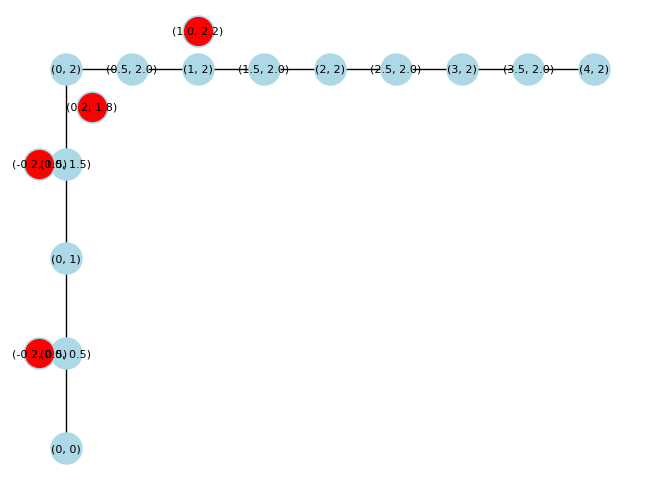

In [15]:
import math
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

states = [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2)]
observations = np.array([(-0.2, 0.5), (-0.2, 1.5), (0.2, 1.8), (1, 2.2)])

def calculate_midpoint(p1, p2):
    return ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)

G = nx.Graph()

for state in states:
    G.add_node(state)

for i in range(len(states) - 1):
    point1 = states[i]
    point2 = states[i + 1]
    midpoint = calculate_midpoint(point1, point2)
    G.add_node(midpoint)
    G.add_edge(point1, midpoint)
    G.add_edge(midpoint, point2)

pos = {state: state for state in states}
for i in range(len(states) - 1):
    midpoint = calculate_midpoint(states[i], states[i + 1])
    pos[midpoint] = midpoint

# Add observations to the graph
for observation in observations:
    G.add_node(tuple(observation))

# Plot the graph with observations
for i, observation in enumerate(observations):
    pos[tuple(observation)] = tuple(observation)

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=8)

# Highlight observation points in a different color
nx.draw_networkx_nodes(G, pos, nodelist=[tuple(obs) for obs in observations], node_color='red', node_size=400)

plt.show()


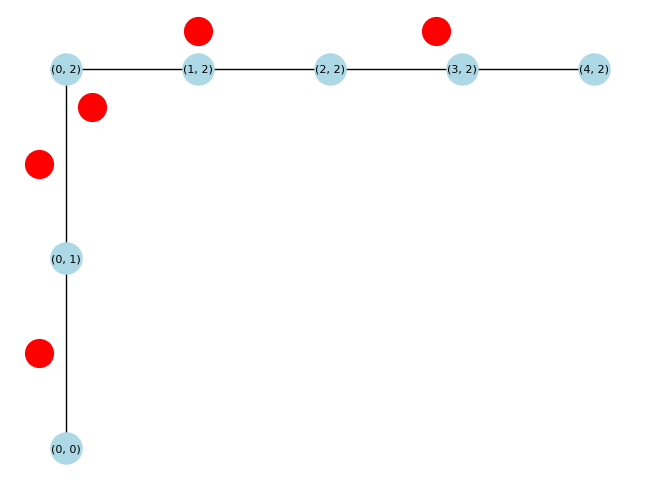

[[0.  0. ]
 [0.  0.5]
 [0.  1. ]
 [0.  1.5]
 [0.  2. ]
 [0.5 2. ]
 [1.  2. ]
 [1.5 2. ]
 [2.  2. ]
 [2.5 2. ]
 [3.  2. ]
 [3.5 2. ]
 [4.  2. ]]


In [89]:
import numpy as np
from math import exp, sqrt, pi
import networkx as nx
import matplotlib.pyplot as plt

states = np.array([(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4,2)])
observations = np.array([(-0.2, 0.5), (-0.2, 1.5), (0.2, 1.8), (1, 2.2), (2.8, 2.2)])
def calculate_midpoint(p1, p2):
    return (p1 + p2) / 2
G = nx.Graph()
states2 = np.empty((0, 2))
midpoints = []  

for i in range(len(states) - 1):
    point1 = states[i]
    point2 = states[i + 1]
    midpoint = calculate_midpoint(point1, point2)
    midpoints.append(midpoint)
    states2 = np.vstack([states2, point1, midpoint])    
    G.add_edge(tuple(point1), tuple(point2))

states2 = np.vstack([states2, states[-1]])

pos = {tuple(state): state for state in states}
for observation in observations:
    pos[tuple(observation)] = observation

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=8)
nx.draw_networkx_nodes(G, pos, nodelist=[tuple(obs) for obs in observations], node_color='red', node_size=400)
plt.show()
print(states2)

Most probable edge sequence (midpoints): [0 1 2 3 4]


/var/folders/g7/pjzz4q115nsb8sw2k_ff0dw80000gn/T/ipykernel_30200/1348108412.py:76: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, width=4, edge_color='green')


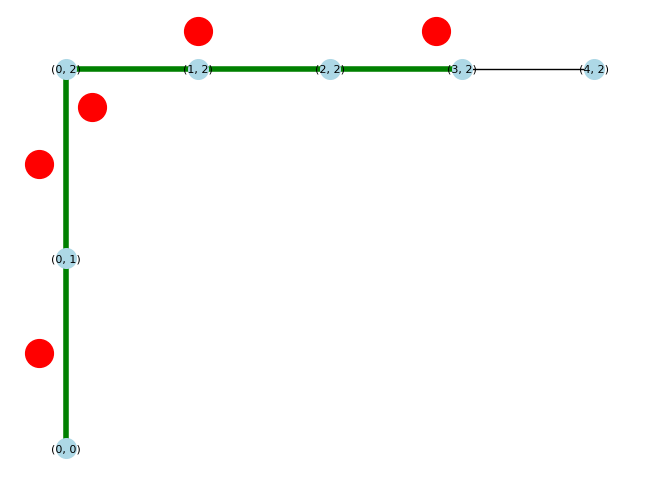

In [91]:
import numpy as np
from math import exp, sqrt, pi
import networkx as nx
import matplotlib.pyplot as plt

pairwise_distances3 = []
for i in range(len(observations) - 1):
    x1, y1 = observations[i]
    x2, y2 = observations[i + 1]
    distance = sqrt((x2 - x1)**2 + (y2 - y1)**2)
    pairwise_distances3.append(distance)

# Initialize TRANS matrix for edges (midpoints)
beta = 0.95  
n3 = len(midpoints)
TRANS = np.zeros((n3, n3))

# Calculate the mean distance for scaling
mean_distance = np.mean(pairwise_distances3)

# Populate TRANS matrix for transitions between midpoints
for i in range(n3):
    for j in range(n3):
        xtemp3 = np.linalg.norm(midpoints[i] - midpoints[j])
        dij3 = abs(xtemp3 - mean_distance)
        TRANS[i, j] = (1 / beta) * exp(-dij3 / beta)
    if np.sum(TRANS[i, :]) > 0:
        TRANS[i, :] = TRANS[i, :] / np.sum(TRANS[i, :])

# Calculate sigz3 and EMIS matrix for edges (midpoints)
sigztemp3 = []
for i in range(len(observations)):
    for j in range(len(midpoints)):
        sigztemp3.append(np.linalg.norm(observations[i] - midpoints[j]))
sigz3 = 1.4 * np.median(sigztemp3)

EMIS = np.zeros((len(midpoints), len(observations)))
for i in range(len(observations)):
    for j in range(len(midpoints)):
        EMIS[j, i] = (1 / (sqrt(2 * pi) * sigz3)) * exp(-0.5 * ((np.linalg.norm(observations[i] - midpoints[j])) / sigz3) ** 2)

# Initialize sequence and PRIOR distribution
seq3 = np.arange(1, len(observations) + 1)
PRIOR3 = np.array([(1 / len(midpoints))] * len(midpoints))
T3 = len(seq3)  
n3 = EMIS.shape[0] 

# Initialize score and prediction matrices for edges
score3 = np.zeros((n3, T3))
pred3 = np.zeros((n3, T3))

# Compute scores and predictions for the first observation
for i in range(n3):
    score3[i, 0] = PRIOR3[i] * EMIS[i, seq3[0] - 1]
for t in range(1, T3):
    for j in range(n3):
        tscore3 = np.zeros(n3)
        for k in range(n3):
            tscore3[k] = score3[k, t - 1] * TRANS[k, j] * EMIS[j, seq3[t] - 1]
        score3[j, t] = np.max(tscore3)
        id3 = np.where(tscore3 == np.max(tscore3))[0][0]
        pred3[j, t] = id3

IT3 = np.zeros(T3, dtype=int)
IT3[-1] = np.argmax(score3[:, -1])
for t in range(T3 - 1, 0, -1):
    IT3[t - 1] = int(pred3[IT3[t], t])
print("Most probable edge sequence (midpoints):", IT3)

highlight_edges = [(tuple(states[i]), tuple(states[i + 1])) for i in IT3]
plt.figure()
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=200, font_size=8)
nx.draw_networkx_nodes(G, pos, nodelist=[tuple(obs) for obs in observations], node_color='red', node_size=400)
nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, width=4, edge_color='green')  


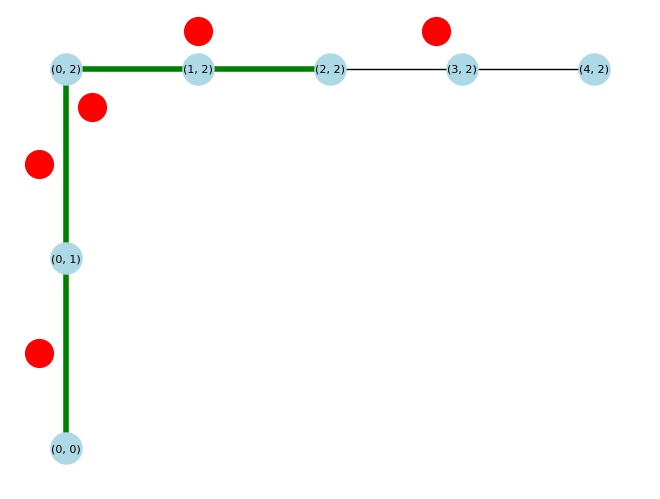

In [90]:
import numpy as np
from math import exp, sqrt, pi
import networkx as nx
import matplotlib.pyplot as plt

pairwise_distances3 = [sqrt((observations[i + 1][0] - observations[i][0])**2 + (observations[i + 1][1] - observations[i][1])**2) for i in range(len(observations) - 1)]

beta = 0.95  
n3 = len(midpoints)
TRANS = np.zeros((n3, n3))

mean_distance = np.mean(pairwise_distances3)

for i in range(n3):
    for j in range(n3):
        dij3 = abs(np.linalg.norm(midpoints[i] - midpoints[j]) - mean_distance)
        TRANS[i, j] = (1 / beta) * exp(-dij3 / beta)
    TRANS[i, :] /= np.sum(TRANS[i, :])

sigz3 = 1.4 * np.median([np.linalg.norm(observations[i] - midpoints[j]) for i in range(len(observations)) for j in range(len(midpoints))])

EMIS = np.array([[1 / (sqrt(2 * pi) * sigz3) * exp(-0.5 * (np.linalg.norm(observations[i] - midpoints[j]) / sigz3) ** 2) for i in range(len(observations))] for j in range(len(midpoints))])

seq3 = np.arange(1, len(observations) + 1)
PRIOR3 = np.ones(len(midpoints)) / len(midpoints)
T3 = len(seq3)  
n3 = EMIS.shape[0] 

score3 = np.zeros((n3, T3))
pred3 = np.zeros((n3, T3))

for i in range(n3):
    score3[i, 0] = PRIOR3[i] * EMIS[i, seq3[0] - 1]

for t in range(1, T3):
    for j in range(n3):
        tscore3 = score3[:, t - 1] * TRANS[:, j] * EMIS[j, seq3[t] - 1]
        score3[j, t] = np.max(tscore3)
        pred3[j, t] = np.argmax(tscore3)

IT3 = np.zeros(T3, dtype=int)
IT3[-1] = np.argmax(score3[:, -1])
for t in range(T3 - 1, 0, -1):
    IT3[t - 1] = int(pred3[IT3[t], t])

highlight_edges = [(tuple(states[IT3[i]]), tuple(states[IT3[i + 1]])) for i in range(len(IT3) - 1)]
plt.figure()
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=8)
nx.draw_networkx_nodes(G, pos, nodelist=[tuple(obs) for obs in observations], node_color='red', node_size=400)
nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, width=4, edge_color='green')
plt.show()
